In [68]:
from core import DataFrame
from io_module import read_csv_chunks
from processing import ChunkProcessor
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

df = DataFrame.from_csv("../data/spotify_songs.csv")

# SQL

## The Graph of Average Track Population by selected var 

In [69]:
def plot_group_popularity(var):
    # 1. Aggregation
    grouped_var = df.groupby(var)
    var_stats = grouped_var.aggregate({
        'track_popularity': 'mean',
        'track_id': 'count'
    })
    
    # 2. Data Preprocessing
    data_list = []
    count_data = var_stats[f'track_id_count']
    pop_data = var_stats[f'track_popularity_mean']
    label_data = var_stats[var]
    
    for i in range(len(label_data)):
        data_list.append({
            'label': str(label_data[i]), # Convert to string to avoid errors
            'pop': pop_data[i] if pop_data[i] is not None else 0,
            'count': count_data[i] if count_data[i] is not None else 0
        })
    
    # Sort by "song count" in descending order
    data_list.sort(key=lambda x: x['count'], reverse=True)
    top_data = data_list[:20]
    
    # Decompose back into lists for matplotlib
    plot_vars = [d['label'] for d in top_data]
    plot_pop = [d['pop'] for d in top_data]
    plot_counts = [d['count'] for d in top_data]
    
    # 3. Plotting
    plt.style.use('ggplot')
    # It is recommended to add this line to avoid residual plots or memory overflow during interaction
    plt.close('all') 
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Left plot: Average Popularity
    ax1.bar(plot_vars, plot_pop, color='skyblue', edgecolor='black')
    ax1.set_title(f'Average Popularity by {var}') # Dynamic title
    ax1.set_xlabel(var)                            # Dynamic X axis
    ax1.set_ylabel('Avg Popularity')
    ax1.tick_params(axis='x', rotation=45)
    ax1.set_ylim(0, 100)
    
    # Right plot: Song Count
    ax2.bar(plot_vars, plot_counts, color='salmon', edgecolor='black')
    ax2.set_title(f'Song Count by {var}')         # Dynamic title
    ax2.set_xlabel(var)                            # Dynamic X axis
    ax2.set_ylabel('Count')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# 4. Build interactive interface (UI)
print("Please select grouping criteria:")
widgets.interact(
    plot_group_popularity, 
    var=widgets.Dropdown(
        options=['playlist_genre', 'playlist_subgenre', 'playlist_name', 'key', 'mode'],
        value='playlist_genre',
        description='Group By:',
    )
)

Please select grouping criteria:


interactive(children=(Dropdown(description='Group By:', options=('playlist_genre', 'playlist_subgenre', 'playl…

<function __main__.plot_group_popularity(var)>

## The trend of popularity with var

In [70]:
# List of numerical features to analyze
feature_options = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo'
]

def plot_trend_with_var(var):
    """
    Plots the relationship between the selected variable and track popularity.
    """
    # 1. Prepare Data
    # Retrieve the list of values for the x-axis (selected variable)
    x_data = df[var]
    
    # Retrieve the list of values for the y-axis (popularity)
    y_data = df['track_popularity']
    
    # 2. Plotting Setup
    # Close previous plots to prevent memory leaks or overlapping figures in notebooks
    plt.close('all')
    
    plt.figure(figsize=(10, 6))
    plt.style.use('ggplot') # Optional: Use a nice style
    
    # Create a scatter plot
    # 'o' = circle marker, alpha=0.1 = high transparency to show density
    plt.plot(x_data, y_data, 'o', alpha=0.1, color='blue')
    
    # 3. Dynamic Labels and Titles
    plt.title(f'Track Popularity vs {var}') # Dynamic title based on selection
    plt.xlabel(var)                          # Dynamic X-axis label
    plt.ylabel('Track Popularity')
    plt.grid(True)
    
    # Display the plot
    plt.show()

# 4. Create the Interactive Interface
print("Select a feature to visualize its relationship with Popularity:")

widgets.interact(
    plot_trend_with_var, 
    var=widgets.Dropdown(
        options=feature_options,
        value='danceability',       # Default selected value
        description='Feature:',
        disabled=False
    )
)

Select a feature to visualize its relationship with Popularity:


interactive(children=(Dropdown(description='Feature:', options=('danceability', 'energy', 'loudness', 'speechi…

<function __main__.plot_trend_with_var(var)>

## Relationship between variables

In [71]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

audio_features = [
    "danceability",
    "energy",
    "acousticness",
    "valence",
    "speechiness",
    "tempo",
    "loudness"
]

audio_features = [f for f in audio_features if f in df.columns]

if "playlist_genre" in df.columns:
    genres = sorted(set(df.data["playlist_genre"]))
    genre_options = ["All"] + genres
else:
    genre_options = ["All"]



feature_x_dd = widgets.Dropdown(
    options=audio_features,
    value=audio_features[0],
    description="X feature:"
)

feature_y_dd = widgets.Dropdown(
    options=["(None)"] + audio_features,
    value="(None)",
    description="Y feature:"
)

genre_dd = widgets.Dropdown(
    options=genre_options,
    value="All",
    description="Genre:"
)

pop_min_slider = widgets.IntSlider(
    description="Min popularity",
    min=0, max=100, step=1, value=0,
    continuous_update=False
)

pop_max_slider = widgets.IntSlider(
    description="Max popularity",
    min=0, max=100, step=1, value=100,
    continuous_update=False
)

btn_refresh = widgets.Button(
    description="Update plots",
    button_style="primary"
)

output_af = widgets.Output()



def filter_indices():
    """Filter row indices based on selected genre and popularity range."""
    indices = []
    use_genre = (genre_dd.value != "All")
    
    for i in range(df.row_count):
        # Filter by genre (if not "All")
        if use_genre:
            g = df.data["playlist_genre"][i]
            if g != genre_dd.value:
                continue
        
        # Filter by popularity range
        pop = df.data.get("track_popularity", [None] * df.row_count)[i]
        if pop is None:
            continue
        if not (pop_min_slider.value <= pop <= pop_max_slider.value):
            continue
        
        indices.append(i)
    
    return indices


def on_update_clicked(b=None):
    with output_af:
        clear_output()
        
        x_col = feature_x_dd.value
        y_col = feature_y_dd.value if feature_y_dd.value != "(None)" else None
        
        indices = filter_indices()
        
        if not indices:
            print("No songs match current filters. Try widening the popularity range or changing genre.")
            return
        
        x_vals, y_vals, pops = [], [], []
        
        for i in indices:
            x = df.data[x_col][i]
            if x is None:
                continue
            
            pop = df.data.get("track_popularity", [None]*df.row_count)[i]
            if pop is None:
                continue
            
            if y_col is not None:
                y = df.data[y_col][i]
                if y is None:
                    continue
                y_vals.append(y)
            
            x_vals.append(x)
            pops.append(pop)
        
        if not x_vals:
            print("No valid numeric values for the selected feature(s).")
            return
        
        # Statistics
        n = len(x_vals)
        avg_x = sum(x_vals) / n
        print(f"Filtered songs: {n}")
        print(f"{x_col}: mean={avg_x:.3f}, min={min(x_vals):.3f}, max={max(x_vals):.3f}")
        if y_col is not None and y_vals:
            avg_y = sum(y_vals) / len(y_vals)
            print(f"{y_col}: mean={avg_y:.3f}, min={min(y_vals):.3f}, max={max(y_vals):.3f}")
        print()
        
        # Plotting
        if y_col is None:
            # Left: Histogram of X feature; Right: Scatter plot of X vs popularity
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            
            axes[0].hist(x_vals, bins=30, edgecolor="black")
            axes[0].set_title(f"Distribution of {x_col}")
            axes[0].set_xlabel(x_col)
            axes[0].set_ylabel("Count")
            
            axes[1].scatter(x_vals, pops, alpha=0.3)
            axes[1].set_title(f"{x_col} vs Popularity")
            axes[1].set_xlabel(x_col)
            axes[1].set_ylabel("Popularity")
            
            plt.tight_layout()
            plt.show()
        else:
            # Left: Histogram of X feature; Right: Scatter plot of X vs Y
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            
            axes[0].hist(x_vals, bins=30, edgecolor="black")
            axes[0].set_title(f"Distribution of {x_col}")
            axes[0].set_xlabel(x_col)
            axes[0].set_ylabel("Count")
            
            axes[1].scatter(x_vals, y_vals, alpha=0.3)
            axes[1].set_title(f"{x_col} vs {y_col}")
            axes[1].set_xlabel(x_col)
            axes[1].set_ylabel(y_col)
            
            plt.tight_layout()
            plt.show()

btn_refresh.on_click(on_update_clicked)


controls_row1 = widgets.HBox([feature_x_dd, feature_y_dd])
controls_row2 = widgets.HBox([genre_dd])
controls_row3 = widgets.HBox([pop_min_slider, pop_max_slider, btn_refresh])

ui_af = widgets.VBox([
    widgets.HTML("<h3> Audio Feature Explorer</h3>"),
    controls_row1,
    controls_row2,
    controls_row3,
    output_af
])

display(ui_af)

on_update_clicked()

## Top N of song or singer

In [72]:
import ipywidgets as widgets
from IPython.display import display

def show_most_popular_singers(top_n):
    # 1. Grouping and Aggregation
    grouped_artist = df.groupby('track_artist')
    artist_stats = grouped_artist.aggregate({
        'track_popularity': 'mean',
        'track_id': 'count'
    })
    
    # 2. Data Extraction
    artists = artist_stats['track_artist']
    avg_popularity = artist_stats['track_popularity_mean']
    song_counts = artist_stats['track_id_count']
    
    # 3. Combine and Sort
    # Zip lists together into a list of tuples: (Artist, Popularity, Count)
    combined_data = list(zip(artists, avg_popularity, song_counts))
    
    # Sort by Popularity (index 1) in descending order. 
    # Handle None values by defaulting to 0.
    combined_data.sort(key=lambda x: x[1] if x[1] is not None else 0, reverse=True)
    
    # 4. Display Output
    print(f"=== The Most Popular {top_n} Singers (by Avg Popularity) ===")
    # Print header with alignment formatting
    print(f"{'Rank':<5} | {'Artist':<25} | {'Pop':<6} | {'Count'}")
    print("-" * 50)
    
    # Safety Check: Ensure we don't request more items than exist in the list
    safe_n = min(top_n, len(combined_data))
    
    for i in range(safe_n):
        artist, pop, count = combined_data[i]
        # Truncate artist name to 25 chars for cleaner display
        print(f"No.{i+1:<4} | {artist[:25]:<25} | {pop:.1f}   | {count}")

# 5. Interactive UI
print("Adjust the slider to change Top N:")

widgets.interact(
    show_most_popular_singers, 
    top_n=widgets.IntSlider(
        value=5,        # Default value
        min=1,          # Minimum value
        max=50,         # Maximum value
        step=1,         # Increment step
        description='Top N:',
        continuous_update=False  # Update only when mouse is released (prevents lag)
    )
);

Adjust the slider to change Top N:


interactive(children=(IntSlider(value=5, continuous_update=False, description='Top N:', max=50, min=1), Output…

## Processing chunk

In [73]:
reader = read_csv_chunks("../data/spotify_songs.csv", chunk_size=1000)
filtered = ChunkProcessor.filter_chunks(
    reader,
    lambda row: row['track_popularity'] > 60
)

for chunk in filtered:
    print(chunk)

track_id             | track_name           | track_artist   | track_popularity | track_album_id       | track_album_name     | track_album_release_date | playlist_name | playlist_id          | playlist_genre | playlist_subgenre | danceability | energy | key | loudness | mode | speechiness | acousticness | instrumentalness | liveness | valence | tempo   | duration_ms
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
6f807x0ima9a1j3VP... | I Don't Care (wit... | Ed Sheeran     | 66               | 2oCs0DGTsRO98Gh5Z... | I Don't Care (wit... | 2019-06-14           | Pop Remix     | 37i9dQZF1DXcZDD7c... | pop            | dance pop         | 0.748        | 0.916  | 6   | -2.

In [74]:
reader = read_csv_chunks("../data/spotify_songs.csv", chunk_size=1000)

group_cols = "playlist_genre"
operations = {
    "track_popularity": "mean", 
    "track_id": "count"         
}

result_df = ChunkProcessor.aggregate_chunks(
    chunk_reader=reader,
    group_by_cols=group_cols,
    agg_dict=operations
)

print(result_df)

playlist_genre | track_popularity_mean | track_id_count
-------------------------------------------------------
pop            | 46.582925049309665   | 5507          
rap            | 44.66184646370474    | 5746          
rock           | 39.55865807018925    | 4951          
latin          | 46.269218350340374   | 5155          
r&b            | 41.73438912366621    | 5431          
edm            | 35.88185222660493    | 6043          

Shape: (6 rows, 3 columns)


---

# NoSQL

In [75]:
from nosql_module import *
print(" Successfully loaded nosql_module.py！")

 Successfully loaded nosql_module.py！


In [76]:
data = load_json("spotify_reviews.json")
print(f" Loaded {len(data)} data entries")
print("First data entry:", data[0])

 Loaded 500 data entries
First data entry: {'user_id': 1, 'track_name': 'Senorita', 'rating': 4, 'review': 'The chorus makes the song feel Fantastic.', 'play_count': 158}


In [77]:
filtered = filter_json(data, "rating", ">", 4)
print(f" Number of high-rated songs: {len(filtered)}")
print(filtered[:3])

 Number of high-rated songs: 111
[{'user_id': 5, 'track_name': 'Levitating', 'rating': 5, 'review': 'Feels so Calm because of the melody.', 'play_count': 58}, {'user_id': 6, 'track_name': 'Circles', 'rating': 5, 'review': 'I really enjoyed the Amazing vocals.', 'play_count': 150}, {'user_id': 8, 'track_name': 'Someone You Loved', 'rating': 5, 'review': 'Feels so Decent because of the rhythm.', 'play_count': 64}]


In [78]:
projected = project_json(filtered, ["track_name", "rating"])
print(" Projected columns (first 5 rows):", projected[:5])

 Projected columns (first 5 rows): [{'track_name': 'Levitating', 'rating': 5}, {'track_name': 'Circles', 'rating': 5}, {'track_name': 'Someone You Loved', 'rating': 5}, {'track_name': 'Blinding Lights', 'rating': 5}, {'track_name': 'Someone You Loved', 'rating': 5}]


In [79]:
grouped = group_and_aggregate(data, "track_name", "rating", "avg")
print(" Average rating of each track:")
for k, v in grouped.items():
    print(f"{k}: {v:.2f}")

 Average rating of each track:
Senorita: 3.27
Happier: 3.03
Circles: 3.07
Believer: 2.45
Levitating: 2.94
Someone You Loved: 3.32
Blinding Lights: 3.29
Sunflower: 2.61
Stay: 3.32
Memories: 3.00
Shape of You: 2.88
Rockstar: 3.19
Dance Monkey: 3.20
Perfect: 2.90
Bad Guy: 2.93


In [80]:
grouped

{'Senorita': 3.272727272727273,
 'Happier': 3.0294117647058822,
 'Circles': 3.0689655172413794,
 'Believer': 2.4545454545454546,
 'Levitating': 2.9361702127659575,
 'Someone You Loved': 3.317073170731707,
 'Blinding Lights': 3.2903225806451615,
 'Sunflower': 2.608695652173913,
 'Stay': 3.3225806451612905,
 'Memories': 3.0,
 'Shape of You': 2.875,
 'Rockstar': 3.193548387096774,
 'Dance Monkey': 3.2,
 'Perfect': 2.896551724137931,
 'Bad Guy': 2.9285714285714284}

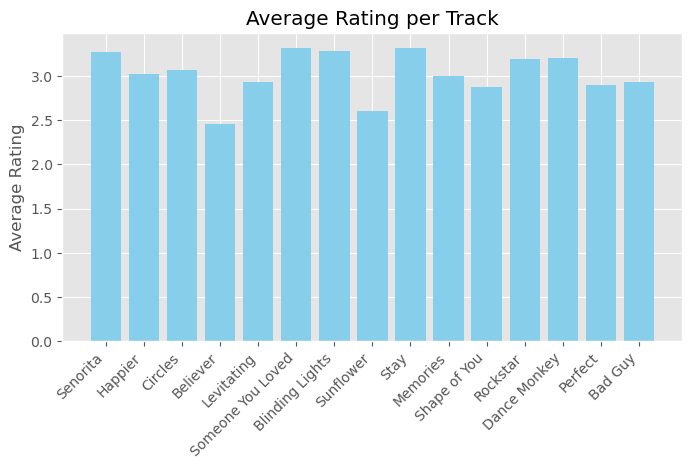

In [81]:
tracks = list(grouped.keys())
ratings = list(grouped.values())

plt.figure(figsize=(8,4))
plt.bar(tracks, ratings, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title("Average Rating per Track")
plt.ylabel("Average Rating")
plt.show()

---

## finding underrated

In [82]:
# 1. Prepare data
raw_data = {
    'track_name': ['Senorita', 'Happier', 'Circles', 'Believer', 'Levitating', 'Someone You Loved', 'Blinding Lights', 'Sunflower', 'Stay', 'Memories', 'Shape of You', 'Rockstar', 'Dance Monkey', 'Perfect', 'Bad Guy'],
    'track_rating_mean': [3.27, 3.03, 3.07, 2.45, 2.94, 3.32, 3.29, 2.61, 3.32, 3.0, 2.88, 3.19, 3.2, 2.90, 2.93],
    'track_popularity_mean': [94.33, 71.33, 72.75, 46.0, 25.0, 61.71, 60.0, 48.0, 94.0, 67.6, 69.5, 72.85, 54.33, 45.67, 30.5]
}
df = DataFrame(raw_data)

# 2. Define filter function (Updated to accept 'top_n')
def filter_and_display(rating, popularity, top_n):
    # Use your filter method
    result = df.filter(lambda row: 
        row['track_rating_mean'] >= rating and 
        row['track_popularity_mean'] <= popularity
    )
    
    # Display statistics
    print(f"Filter conditions: Rating >= {rating:.1f} and Popularity <= {popularity}")
    print(f"Found {result.row_count} records. Showing top {top_n}:")
    print("-" * 50)
    
    if result.row_count > 0:
        # Use the .head(n) method from your DataFrame class to slice the data
        print(result.head(top_n))
    else:
        print("No songs match the criteria.")

# 3. Build widgets
# Rating slider
rating_slider = widgets.FloatSlider(
    value=2.5,          
    min=0.0, max=5.0,   
    step=0.1,           
    description='Rating:',
    continuous_update=False
)

# Popularity slider
popularity_slider = widgets.IntSlider(
    value=100,          
    min=0, max=100,
    step=5,
    description='Popularity:',
    continuous_update=False
)

# [NEW] Rows to display slider
top_n_slider = widgets.IntSlider(
    value=5,           # Default to showing 5 rows
    min=1, max=15,     # Range (max 15 because that's the total data size here)
    step=1,
    description='Show Rows:',
    continuous_update=False
)

# 4. Build UI
# Add the new slider to the VBox layout
ui = widgets.VBox([rating_slider, popularity_slider, top_n_slider])

# Bind the new slider to the 'top_n' parameter
out = widgets.interactive_output(filter_and_display, {
    'rating': rating_slider, 
    'popularity': popularity_slider,
    'top_n': top_n_slider  # Binding the new parameter
})

# 5. Display
display(ui, out)

Output()

## finding overrated

In [83]:
# 1. Prepare data (Same as before)
raw_data = {
    'track_name': ['Senorita', 'Happier', 'Circles', 'Believer', 'Levitating', 'Someone You Loved', 'Blinding Lights', 'Sunflower', 'Stay', 'Memories', 'Shape of You', 'Rockstar', 'Dance Monkey', 'Perfect', 'Bad Guy'],
    'track_rating_mean': [3.27, 3.03, 3.07, 2.45, 2.94, 3.32, 3.29, 2.61, 3.32, 3.0, 2.88, 3.19, 3.2, 2.90, 2.93],
    'track_popularity_mean': [94.33, 71.33, 72.75, 46.0, 25.0, 61.71, 60.0, 48.0, 94.0, 67.6, 69.5, 72.85, 54.33, 45.67, 30.5]
}
df = DataFrame(raw_data)

# 2. Define filter function (UPDATED LOGIC)
def filter_and_display(rating, popularity, top_n):
    # Apply the new filter conditions:
    # Rating <= selected value
    # Popularity >= selected value
    result = df.filter(lambda row: 
        row['track_rating_mean'] <= rating and 
        row['track_popularity_mean'] >= popularity
    )
    
    # Display statistics
    print(f"Filter conditions: Rating <= {rating:.1f} and Popularity >= {popularity}")
    print(f"Found {result.row_count} records. Showing top {top_n}:")
    print("-" * 50)
    
    if result.row_count > 0:
        # Show specific number of rows
        print(result.head(top_n))
    else:
        print("No songs match the criteria.")

# 3. Build widgets
# Rating slider
rating_slider = widgets.FloatSlider(
    value=3.5,          # Adjusted default value to make sense with <= logic
    min=0.0, max=5.0,   
    step=0.1,           
    description='Max Rating:', # Changed label to reflect logic
    continuous_update=False
)

# Popularity slider
popularity_slider = widgets.IntSlider(
    value=50,           # Adjusted default value to make sense with >= logic
    min=0, max=100,
    step=5,
    description='Min Pop:',    # Changed label to reflect logic
    continuous_update=False
)

# Rows to display slider
top_n_slider = widgets.IntSlider(
    value=5,           
    min=1, max=15,     
    step=1,
    description='Show Rows:',
    continuous_update=False
)

# 4. Build UI
ui = widgets.VBox([rating_slider, popularity_slider, top_n_slider])

# Bind widgets
out = widgets.interactive_output(filter_and_display, {
    'rating': rating_slider, 
    'popularity': popularity_slider,
    'top_n': top_n_slider
})

# 5. Display
display(ui, out)

Output()

## testing texture